In [9]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())



['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-0

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2


Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:01.510' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.130' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-0

3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2


...

Set DATE-AVG to '2024-09-08T11:31:04.265' from MJD-AVG.
Set DATE-END to '2024-09-08T12:43:52.463' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.803760 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291894033.527 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:39:49.277' from MJD-AVG.
Set DATE-END to '2024-09-08T12:52:42.510' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.797166 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291845460.779 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

9.491651972183757e-10 deg2


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.524574264515582e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

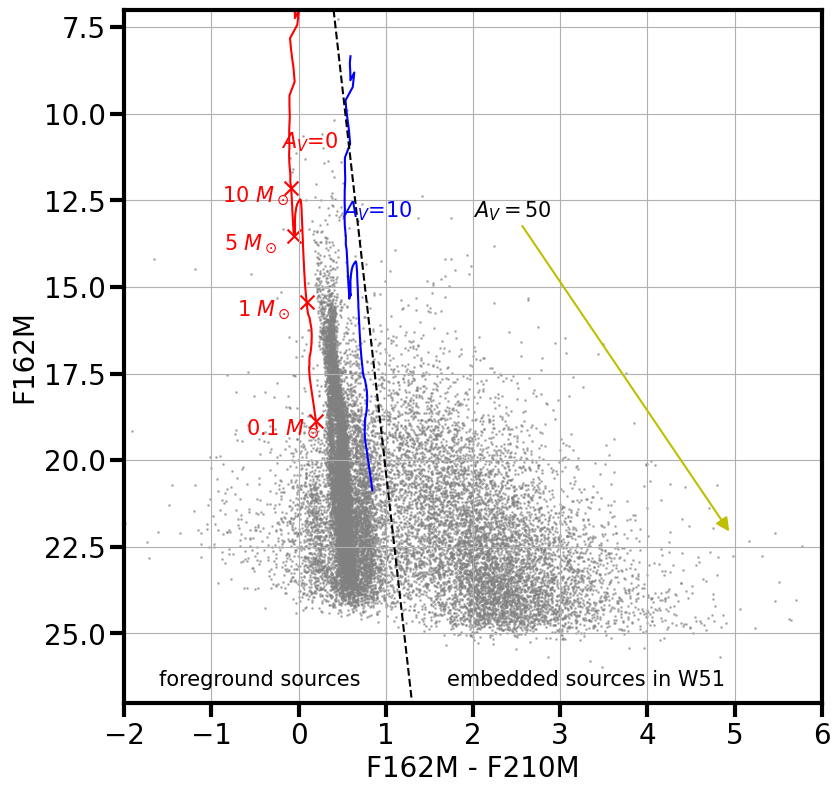

In [10]:
import matplotlib as mpl
from matplotlib.path import Path
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

plt.rcParams['axes.labelsize']=20 
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['axes.titlesize']=20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f162m_mag[0], s=1, c='gray', alpha=0.5)

age_idx = logage_av0 == 6
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx], color='r')

ext = CT06_MWLoc()
#plot isochrone with Av=10
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*10, 
F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*10, color='b')

idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F140Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F140Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F140Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F140Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F140Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

A_K_scale = 5
A_V_scale = A_K_scale * 10
#ax.plot([isochrone_x_start, isochrone_x_end], [isocrhone_y_start, isocrhone_y_end], color='r', linestyle='--')
#ax1.plot([isochrone_x_start+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale, isochrone_x_end+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale], 
#[isocrhone_y_start+(ext(1/1.82/u.um))*A_V_scale, isocrhone_y_end+(ext(1/1.82/u.um))*A_V_scale], color='r', linestyle='--')
# extrapolate the linear part of the isochrone to the left and right by 0.5 mag in color

# and plot
#x_vals = np.array([-1, 2])
#y_vals = color_slope * x_vals + color_intercept
#ax.plot(x_vals, y_vals, color='r', linestyle='--')
for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax.scatter(F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass], color='r', marker='x', s=100)
    ax.annotate(f'{mass} $M_\odot$', (F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(-50,-10), ha='left', color='r', fontsize=15)
plot_extvec_cmd(ax, ('f162m', 'f210m'), ('f162m',), extvec_scale=50, start=(2,13))

ax.text(-0.2, 11, r'$A_V$=0', fontsize=15, color='r')
ax.text(0.5, 13, r'$A_V$=10', fontsize=15, color='b')

ax.text(1.7, 26.5, 'embedded sources in W51', fontsize=15, color='k')
ax.text(-1.6, 26.5, 'foreground sources', fontsize=15, color='k')
#ax.annotate('embedded sources in W51', xy=(2, 26.5), xytext=(1.4, 26.5), ha='left', color='k', fontsize=15)
#ax.annotate('foreground sources', xy=(0, 26.5), xytext=(1, 26.5), ha='left', color='k', fontsize=15)
ax.plot([0.4,1.3], [7, 27], c='k', ls='dashed')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27,7)
ax.set_xlim(-2,6)
ax.grid()
plt.savefig('cmd.png', bbox_inches='tight')
plt.show()





In [11]:
def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))

color1: ('f162m', 'f210m') mag1: ('f162m',)
w_color1_1: 1.62 um w_color1_2: 2.1 um w_mag1: 1.62 um


Best n_components (BIC): 4
Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.382330074074073 3.4739712 1.7993024000000004 1.454796
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.4357638888888875 3.6726315789473687 1.6323076923076927 0.69
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.377005929042962 3.662529750810622 1.6526084768147404 1.0894231111576114
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.15745734947461 3.598397287717673 1.9293004729897925 0.9708737864077621
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
Extinction vector not plotted: Input x outside of rang

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


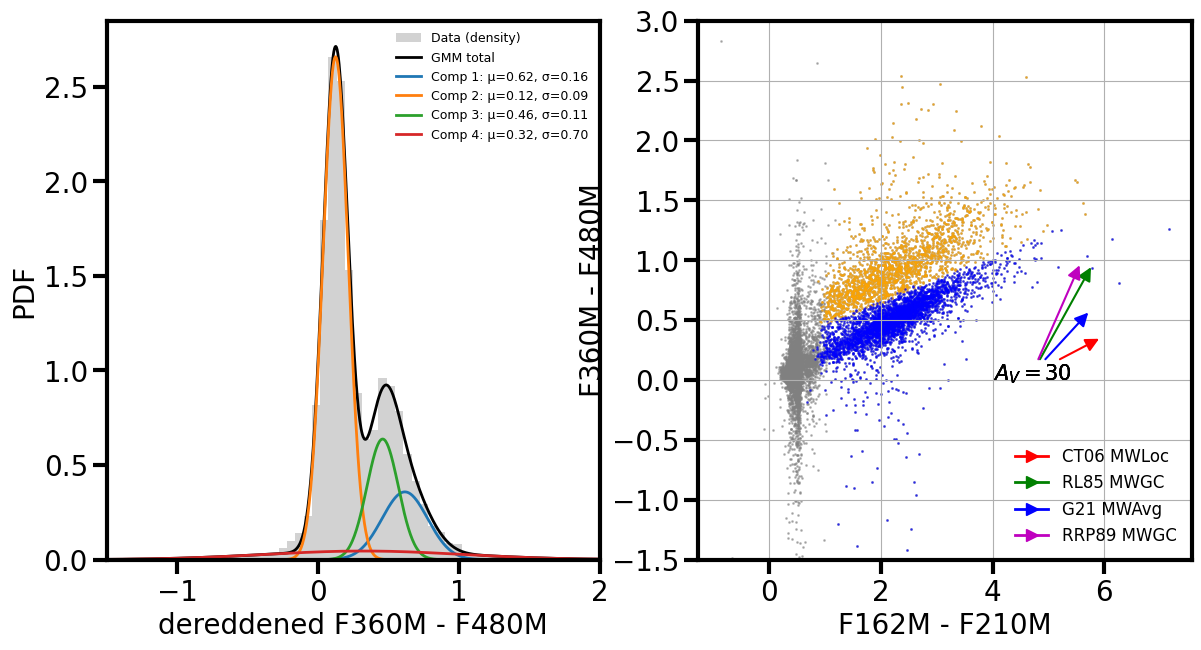

In [12]:
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, G21_MWAvg,RRP89_MWGC, G24_SMCAvg
from sklearn.mixture import GaussianMixture

def plot_extvec_ccd(ax, color1, color2, ext=CT06_MWLoc(), extvec_scale=30, start=None,
                    color='y', head_width=0.5, color1_data=None, color2_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_color2 = np.nanmean(color2_data)
        std_color1 = np.nanstd(color1_data)
        std_color2 = np.nanstd(color2_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        if e_3 - e_4 < 0:
            std_color2 *= -1
    
        start2 = (mean_color1 + 2*std_color1, mean_color2 + 2*std_color2)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]), fontsize=fontsize,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

def gaussian_decomposition(color, color_label, title=None, n_components=None, return_boundary=False, ax=None):
    
    x = np.asarray(color)
    x = x[np.isfinite(x)].reshape(-1, 1)
    
    n_components_grid = range(1, 6)
    if n_components is None:
        
        models, bics, labels, probs = [], [], [], []
        for k in n_components_grid:
            gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=20)
            gmm_k.fit(x)
            label = gmm_k.predict(x)
            prob = gmm_k.predict_proba(x)
            models.append(gmm_k)
            bics.append(gmm_k.bic(x))
            labels.append(label)
            probs.append(prob)


        gmm = models[np.argmin(bics)]
        probs_best = probs[np.argmin(bics)]
        print(f"Best n_components (BIC): {gmm.n_components}")

    else:

        gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=50)
        gmm.fit(x)
        probs_best = gmm.predict_proba(x)

    # Evaluate total PDF and each component PDF
    xgrid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(xgrid)
    pdf = np.exp(logprob)
    resp = gmm.predict_proba(xgrid)
    pdf_components = resp * pdf[:, None]

    # Plot histogram + GMM decomposition
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(x.ravel(), bins=80, density=True, alpha=0.35, color='gray', label='Data (density)')
    ax.plot(xgrid, pdf, 'k-', lw=2, label='GMM total')

    for i in range(gmm.n_components):
        ax.plot(
            xgrid, pdf_components[:, i],
            lw=2, label=f'Comp {i+1}: μ={gmm.means_[i,0]:.2f}, σ={np.sqrt(gmm.covariances_[i,0,0]):.2f}'
        )
    ax.set_xlabel(f'dereddened {color_label[0]} - {color_label[1]}')
    ax.set_ylabel('PDF')
    ax.set_title(title)
    ax.legend(fontsize=9, frameon=False)

    

    

    # get the index of component that has highest PDFpeak
    highest_peak_component = np.argmax(np.max(pdf_components, axis=0))
    if return_boundary:
        # get the index of componet that has the second highest PDF peak
        second_highest_peak_component = np.argsort(np.max(pdf_components, axis=0))[-2]

        if gmm.means_[highest_peak_component, 0] > gmm.means_[second_highest_peak_component, 0]:
            cross_section = np.min(np.where((pdf_components[:, highest_peak_component] > pdf_components[:, second_highest_peak_component])&
                                            (xgrid[:, 0] < gmm.means_[highest_peak_component, 0])&
                                            (xgrid[:, 0] > gmm.means_[second_highest_peak_component, 0]))[0])
        else:
            cross_section = np.min(np.where((pdf_components[:, second_highest_peak_component] > pdf_components[:, highest_peak_component])&
                                            (xgrid[:, 0] < gmm.means_[second_highest_peak_component, 0])&
                                            (xgrid[:, 0] > gmm.means_[highest_peak_component, 0]))[0])



        return gmm, highest_peak_component, xgrid[cross_section]
    else:
        return gmm, highest_peak_component

# indexing red sources placted right side of the demarcation line
# demarcation line connecting two points (0.4, 7) and (1.3, 27)


line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4

idx_red_sources = f162 - (line_slope * (f162 - f210) + line_intercept) < 0


fig = plt.figure(figsize=(14, 7))

ax_proj = fig.add_subplot(121)
color_long_dereddened = f360-f480 - av_estimate * (ext(1/3.60/u.um) - ext(1/4.80/u.um))

gmm, peak_ind, boundary_long = gaussian_decomposition(color_long_dereddened[idx_red_sources], ('F360M', 'F480M'), title=None, return_boundary=True, ax=ax_proj)
ax_proj.set_xlim(-1.5,2)

idx_upper = color_long_dereddened[idx_red_sources] > boundary_long
idx_lower = color_long_dereddened[idx_red_sources] <= boundary_long

ax = fig.add_subplot(122)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][idx_red_sources][idx_upper] - f210m_mag[0][idx_red_sources][idx_upper], 
        f360m_mag[0][idx_red_sources][idx_upper]-f480m_mag[0][idx_red_sources][idx_upper], s=1, c='orange', alpha=0.5)

ax.scatter(f162m_mag[0][idx_red_sources][idx_lower] - f210m_mag[0][idx_red_sources][idx_lower], 
        f360m_mag[0][idx_red_sources][idx_lower]-f480m_mag[0][idx_red_sources][idx_lower], s=1, c='blue', alpha=0.5)


colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f162m', 'f210m'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=30, color=c,
                      start=(4,0), label=labels)
"""
vertices_upper = [(2,0.45), (2,0.8), (7, 1.6), (7, 1.1)]
vertices_lower = [(2.2,0.2), (2.2,0.35 ), (7,0.9), (7, 0.6)]
polygon1 = Polygon(vertices_upper, closed=True, fill=False, edgecolor='magenta', linewidth=2, label='upper branch')
polygon2 = Polygon(vertices_lower, closed=True, fill=False, edgecolor='green', linewidth=2, label='lower branch')
ax.add_patch(polygon1)
ax.add_patch(polygon2)
"""
ax.grid()
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F360M - F480M')
ax.set_ylim(-1.5,3)
plt.savefig('ccd.png', bbox_inches='tight')
ax.legend(fontsize=12, frameon=False)
plt.show()




Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
8.970550123456789 5.7899519999999995 2.998837333333334 2.42466
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
9.05960648148148 6.121052631578948 2.720512820512821 1.15
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
8.961676548404936 6.104216251351036 2.754347461357901 1.8157051852626855
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
8.59576224912435 5.997328812862788 3.2155007883163207 1.6181229773462702
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg 

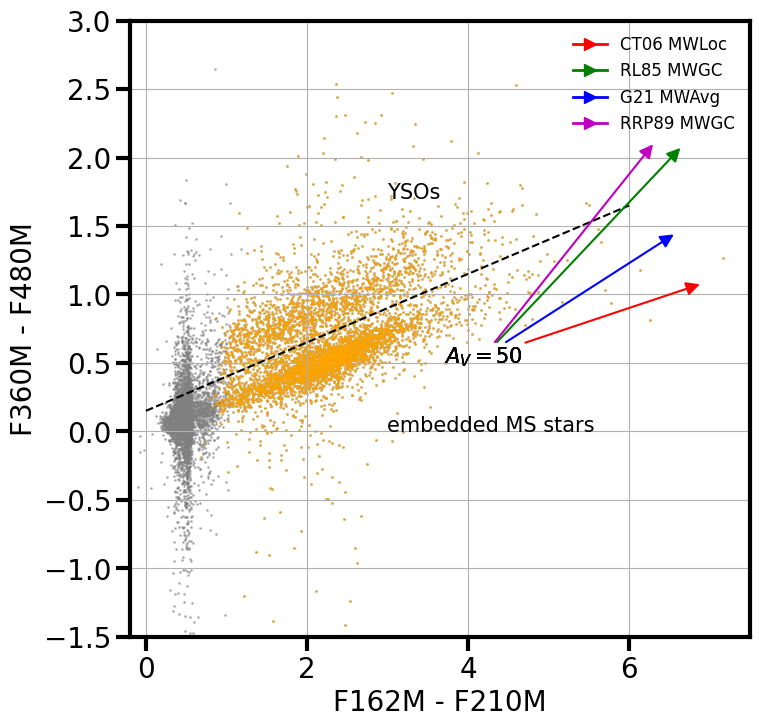

In [13]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][idx_red_sources] - f210m_mag[0][idx_red_sources],
        f360m_mag[0][idx_red_sources]-f480m_mag[0][idx_red_sources], s=1, c='orange', alpha=0.5)
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f162m', 'f210m'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(3.7,0.5), label=labels)
ax.plot([0,6], [0.15, 1.65], c='k', ls='dashed')
ax.grid()
ax.text(3,1.7, 'YSOs', fontsize=15, color='k')
ax.text(3,0, 'embedded MS stars', fontsize=15, color='k')
plt.xlabel('F162M - F210M')
plt.ylabel('F360M - F480M')
ax.set_ylim(-1.5,3)
ax.set_xlim(-0.2,7.5)
ax.legend(fontsize=12, frameon=False)
plt.savefig('ccd.png', bbox_inches='tight')



In [14]:
# idx for sources above/below the line
upper_idx = f360-f480 > 0.15 + (1.5/6)*(f162-f210)
lower_idx = f360-f480 <= 0.15 + (1.5/6)*(f162-f210)